# Décomposition de la progressivité socio-fiscale : combien coûte +100 € de revenu disponible ?

**Objectif.** Pour chaque niveau de salaire, mesurer ce que doit débourser l'employeur (coût du travail
supplémentaire) pour augmenter le **revenu disponible** de son salarié de **100 € par mois**, et décomposer
ce surcoût entre :

- le transfert « logique » de 100 € ;
- la hausse des **cotisations patronales** à taux fixe ;
- la **perte d'allègements généraux** de cotisations patronales (pente Fillon) ;
- la hausse des **cotisations salariales et de la CSG-CRDS** ;
- la hausse de l'**impôt sur le revenu** ;
- la perte de **prime d'activité** ;
- la perte d'**allocations logement (APL)** ;
- la perte de **RSA** et des **autres prestations** (AF, complément familial, ARS...).

**Source et méthode.** Le calcul du revenu disponible réplique en Python le modèle de cas types
**EDIFIS de la DREES** (`edifis-main` : `R/bareme.R`, `R/base.R`, `R/cas-type.R`).
Le notebook est calé sur la **législation au 1er janvier 2026** : paramètres de la maquette DREES
2025 (`data/Maquette_cas_types_2025.xls`, feuille « Barème ») actualisés avec les codes
`MFrance1erjanvier2026.R` / `MFrance1eravril26.R` du dossier PAproject (SMIC 1 823,03 €, PASS
4 005 €, barème IR 2026, prime d'activité, réforme des allègements). Les prestations (RSA, APL,
AF...) gardent leurs valeurs 2025, encore en vigueur au 1er janvier 2026 ; la revalorisation
d'avril 2026 des prestations n'est pas intégrée (hors PA, traitée dans le scénario du 1er juin).
La décomposition marginale reprend la méthode de `contribution100deRD.R` (interpolation de chaque
composante au salaire cible qui procure +100 € de revenu disponible). La section 5 compare les
barèmes 2023 → 2026 ; les sections 6 et 7 sont interactives.

**Hypothèses de périmètre** (cas types « salariés » de l'application Edifis) : pas de chômage (ARE),
pas d'AAH ni d'ASS, recours complet aux prestations, locataire du parc privé sauf mention contraire.
La taxe d'habitation est supprimée (législation 2025).

> **Note technique** : dans la maquette 2025, les seuils des bandeaux maladie (2,25 SMIC gelé =
> 3 931,20 €) et famille (3,3 SMIC gelé = 5 765,76 €) sont exprimés **en euros** alors que le code R
> de la DREES les compare encore à un pourcentage de SMIC (la condition devient toujours vraie).
> On applique ici l'interprétation économiquement correcte : comparaison du salaire brut en euros.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from dataclasses import replace as dc_replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from edifis_model import (load_bareme, build_bareme_2026, simulate, decompose_plus100,
                          decompose_cascade, MECANISMES,
                          CAS_TYPES, CasType, LABELS_FR, COULEURS, DECOMP_COLS)

plt.rcParams.update({"figure.dpi": 105, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True, "font.size": 10})
pd.set_option("display.width", 200)

# ── Barème principal du notebook : 1er JANVIER 2026 ─────────────────────────
# (maquette DREES 2025 + paramètres 2026 des codes MFrance : SMIC 1 823,03 €,
#  PASS 4 005 €, IR 2026, PA 633,21/184,27, réforme des allègements.
#  Les prestations RSA/APL/AF gardent leurs valeurs 2025, encore en vigueur
#  au 1er janvier 2026 — la revalorisation d'avril n'est pas intégrée.)
bareme = build_bareme_2026("janvier")
SMIC_B = bareme["smic_b"]
LABEL_LEG = "législation au 1er janvier 2026"

# le conjoint du cas type biactif est calé sur le SMIC 2026
CAS_TYPES["couple_biactif_smic_2enf"] = dc_replace(
    CAS_TYPES["couple_biactif_smic_2enf"], sal_brut_conjoint=SMIC_B,
    label="Couple biactif (conjoint au SMIC 2026), 2 enfants (6-10 et 11-13 ans), locataire")

print(f"Barème {LABEL_LEG} : {len(bareme)} paramètres")
print(f"SMIC brut mensuel = {SMIC_B:,.2f} €  |  SMIC net mensuel = {bareme['smic_n']:,.2f} €")

Barème législation au 1er janvier 2026 : 233 paramètres
SMIC brut mensuel = 1,823.03 €  |  SMIC net mensuel = 1,443.11 €


## 1. Choix du cas type

Les principaux cas types de l'application Edifis sont prédéfinis. **Modifier `CHOIX` ci-dessous**
pour changer de cas type (ou construire un `CasType` sur mesure : nombre d'enfants par âge, salaire
du conjoint, statut d'occupation du logement, etc.).

In [2]:
for cle, ct in CAS_TYPES.items():
    print(f"  {cle:28s} -> {ct.label}")

# ============================================================
CHOIX = "celibataire"          # <-- MODIFIER ICI le cas type
# ============================================================

cas = CAS_TYPES[CHOIX]
# Exemple de cas type sur mesure (décommenter pour l'utiliser) :
# cas = CasType(label="Couple biactif (conjoint à 1,5 SMIC), 2 enfants", n0=2,
#               nb_enft_610=1, nb_enft_1113=1, sal_brut_conjoint=1.5*SMIC_B)

print(f"\nCas type sélectionné : {cas.label}")

  celibataire                  -> Célibataire sans enfant, locataire
  celibataire_proprietaire     -> Célibataire sans enfant, propriétaire
  monoparent_1enf              -> Famille monoparentale, 1 enfant (6-10 ans), locataire
  monoparent_2enf              -> Famille monoparentale, 2 enfants (6-10 et 11-13 ans), locataire
  couple_monoactif_0enf        -> Couple monoactif sans enfant, locataire
  couple_monoactif_2enf        -> Couple monoactif, 2 enfants (6-10 et 11-13 ans), locataire
  couple_monoactif_3enf        -> Couple monoactif, 3 enfants (3-5, 6-10 et 11-13 ans), locataire
  couple_biactif_smic_2enf     -> Couple biactif (conjoint au SMIC 2026), 2 enfants (6-10 et 11-13 ans), locataire

Cas type sélectionné : Célibataire sans enfant, locataire


## 2. Revenu disponible et transferts le long de l'échelle des salaires

Le graphique ci-dessous montre, pour le cas type choisi, la composition du revenu disponible mensuel
en fonction du salaire brut (en points de SMIC) : salaire net (après CSG-CRDS), prestations
(prime d'activité, APL, RSA, prestations familiales) et impôt sur le revenu (en négatif).

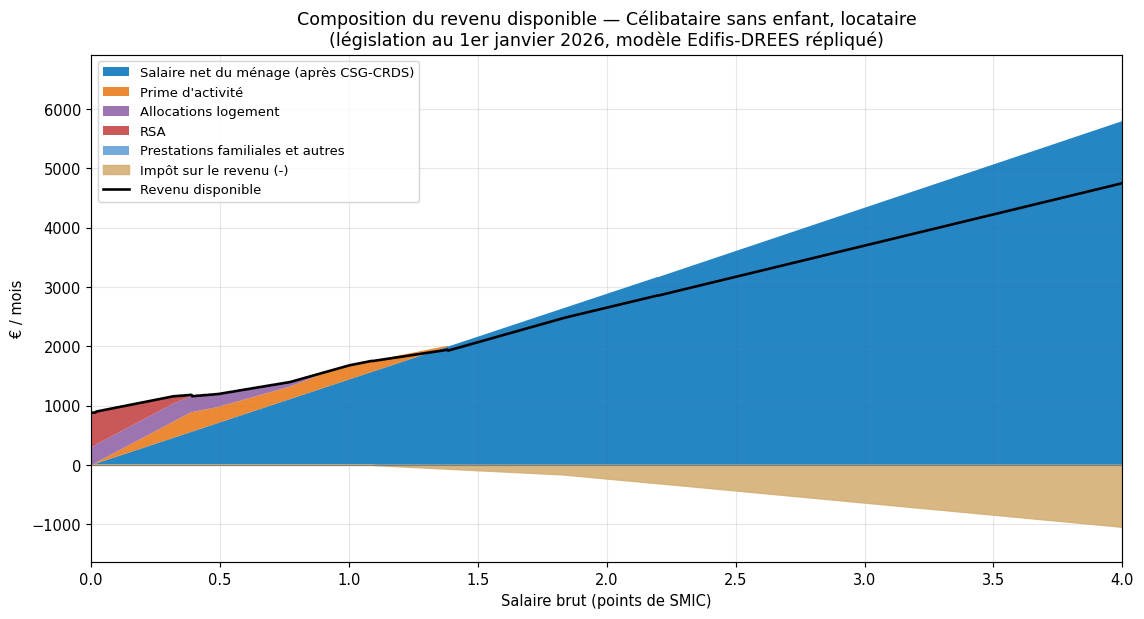

In [3]:
df = simulate(cas, bareme, brut_max=4.5, pas=5.0)

x = df["pts_smic"]
fig, ax = plt.subplots(figsize=(11, 6))
empil = [
    ("rev_trav_net",   "Salaire net du ménage (après CSG-CRDS)", "#0071B9"),
    ("mont_PA",        "Prime d'activité",                        "#E87511"),
    ("AL",             "Allocations logement",                    "#8B5CA5"),
    ("mont_RSA",       "RSA",                                     "#C13B3B"),
    ("presta_famille", "Prestations familiales et autres",        "#5B9BD5"),
]
ax.stackplot(x, [np.clip(df[c], 0, None) for c, _, _ in empil],
             labels=[l for _, l, _ in empil], colors=[c for _, _, c in empil], alpha=0.85)
ax.fill_between(x, 0, -df["imp_recouvr"], color="#D5B076", alpha=0.9,
                label="Impôt sur le revenu (-)")
ax.plot(x, df["rev_disp"], color="black", lw=1.8, label="Revenu disponible")
ax.set_xlim(0, 4); ax.set_xlabel("Salaire brut (points de SMIC)")
ax.set_ylabel("€ / mois"); ax.axhline(0, color="grey", lw=0.8)
ax.set_title(f"Composition du revenu disponible — {cas.label}\n({LABEL_LEG}, modèle Edifis-DREES répliqué)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

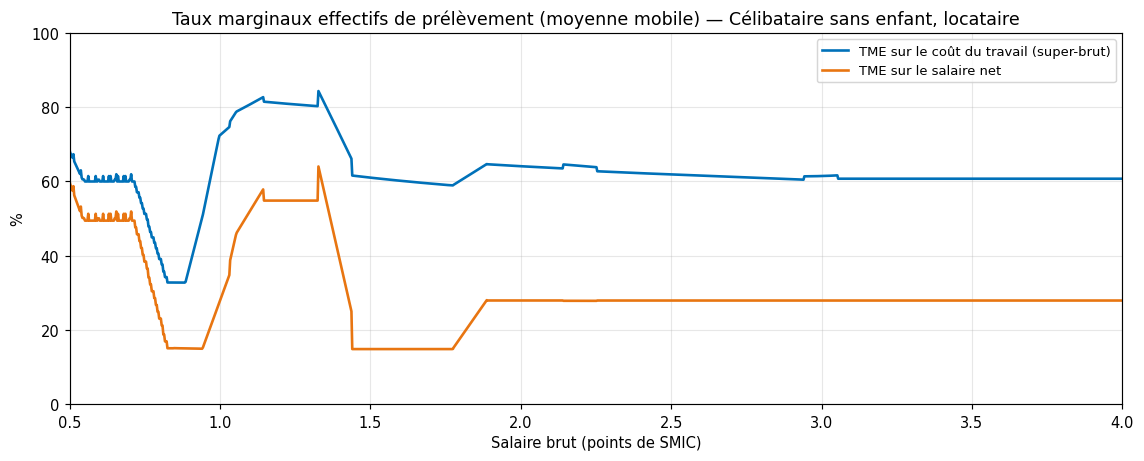

In [4]:
# Taux marginaux effectifs de prélèvement : quelle part d'un euro de plus
# (de salaire net / de coût du travail) ne se retrouve PAS en revenu disponible ?
lisse = lambda s: s.rolling(41, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df["pts_smic"], 100*lisse(df["TMI_superbrut"]), color="#0071B9", lw=1.8,
        label="TME sur le coût du travail (super-brut)")
ax.plot(df["pts_smic"], 100*lisse(df["TMI_net"]), color="#E87511", lw=1.8,
        label="TME sur le salaire net")
ax.set_xlim(0.5, 4); ax.set_ylim(0, 100)
ax.set_xlabel("Salaire brut (points de SMIC)"); ax.set_ylabel("%")
ax.set_title(f"Taux marginaux effectifs de prélèvement (moyenne mobile) — {cas.label}")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 3. Décomposition du surcoût employeur pour +100 € de revenu disponible

**Méthode** (identique à `contribution100deRD.R`) : pour chaque salaire brut initial, on cherche par
interpolation le salaire brut **cible** tel que le revenu disponible du ménage augmente de 100 €.
On calcule ensuite la variation de chaque composante entre la situation initiale et la cible.
Par construction :

`Δ coût du travail = 100 € + Δ cot. patronales + perte d'allègements + Δ cot. salariales/CSG
+ Δ IR + perte de PA + perte d'APL + perte de RSA + perte d'autres prestations`

La colonne `check` vérifie cette identité comptable (doit être ≈ 0).

Attention, composantes négatives tronquées sur le graphique : {'delta_perte_exo': np.float64(-1.8658313447079422)}


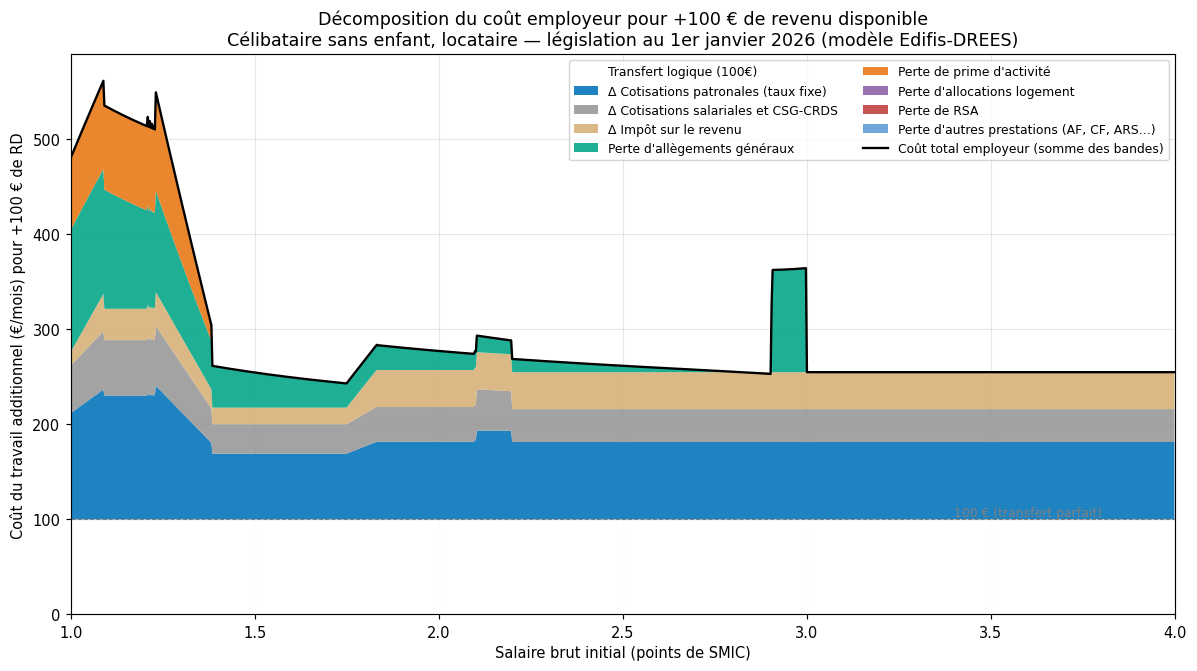

In [5]:
decomp = decompose_plus100(df, delta_rd=100.0)

ordre_bandes = ["transfert", "delta_cot_pat", "delta_cot_sal", "delta_ir",
                "delta_perte_exo", "delta_perte_pa", "delta_perte_al",
                "delta_perte_rsa", "delta_perte_pf"]

zone = decomp[(decomp["pts_smic"] >= 1.0) & (decomp["pts_smic"] <= 4.0)].dropna(subset=["check"])

# bandes >= 0 seulement (d'éventuels petits négatifs liés aux effets de seuil sont tronqués)
neg = {c: zone[c].min() for c in ordre_bandes if zone[c].min() < -1}
if neg:
    print("Attention, composantes négatives tronquées sur le graphique :", neg)

fig, ax = plt.subplots(figsize=(11.5, 6.5))
ax.stackplot(zone["pts_smic"], [np.clip(zone[c], 0, None) for c in ordre_bandes],
             labels=[LABELS_FR[c] for c in ordre_bandes],
             colors=[COULEURS[LABELS_FR[c]] for c in ordre_bandes],
             alpha=0.88, edgecolor="none")
ax.plot(zone["pts_smic"], zone["delta_cout_travail"], color="black", lw=1.6,
        label="Coût total employeur (somme des bandes)")
ax.axhline(100, ls="--", color="grey", lw=0.8)
ax.annotate("100 € (transfert parfait)", xy=(3.4, 104), color="grey", fontsize=8.5)
ax.set_xlabel("Salaire brut initial (points de SMIC)")
ax.set_ylabel("Coût du travail additionnel (€/mois) pour +100 € de RD")
ax.set_title(f"Décomposition du coût employeur pour +100 € de revenu disponible\n{cas.label} — {LABEL_LEG} (modèle Edifis-DREES)")
ax.legend(loc="upper right", fontsize=8.5, ncol=2)
ax.set_xlim(1, 4)
plt.tight_layout(); plt.show()

In [6]:
# Tableau aux points clés de l'échelle des salaires
points = [1.0, 1.1, 1.2, 1.3, 1.5, 1.7, 2.0, 2.5, 3.0]
idx = [(decomp["pts_smic"] - p).abs().idxmin() for p in points]
cols = (["pts_smic", "salaire_brut", "rev_disp", "delta_brut", "delta_cout_travail"]
        + [n for n, _ in DECOMP_COLS.values()] + ["check"])
tableau = decomp.loc[idx, cols].round(1)
tableau.columns = ["SMIC", "Brut (€)", "RD (€)", "Δ brut", "Δ coût travail",
                   "Δ cot. pat.", "Perte allèg.", "Δ cot. sal.", "Δ IR",
                   "Perte PA", "Perte APL", "Perte RSA", "Perte autres presta", "check"]
tableau

,SMIC,Brut (€),RD (€),Δ brut,Δ coût travail,Δ cot. pat.,Perte allèg.,Δ cot. sal.,Δ IR,Perte PA,Perte APL,Perte RSA,Perte autres presta,check
365,1.0,1825.0,1680.9,240.7,480.8,111.8,128.3,50.2,14.4,76.1,-0.0,-0.0,-0.0,-0.0
401,1.1,2005.0,1759.2,279.8,533.2,130.0,123.4,58.3,33.0,88.5,-0.0,-0.0,-0.0,0.0
438,1.2,2190.0,1825.4,279.8,514.2,130.0,104.5,58.3,33.0,88.5,-0.0,-0.0,-0.0,-0.0
474,1.3,2370.0,1889.7,243.3,435.3,113.1,78.9,50.7,28.7,63.9,-0.0,-0.0,-0.0,0.0
547,1.5,2735.0,2071.7,148.4,254.3,69.0,36.9,30.9,17.5,-0.0,-0.0,-0.0,-0.0,0.0
620,1.7,3100.0,2317.6,148.4,244.8,69.0,27.4,30.9,17.5,-0.0,-0.0,-0.0,-0.0,-0.0
729,2.0,3645.0,2652.9,175.4,276.9,81.5,20.1,36.6,38.8,-0.0,-0.0,-0.0,-0.0,0.0
912,2.5,4560.0,3174.3,173.4,261.3,81.3,6.7,34.6,38.8,-0.0,-0.0,-0.0,-0.0,0.0
1094,3.0,5470.0,3699.2,173.4,254.7,81.3,-0.0,34.6,38.8,-0.0,-0.0,-0.0,-0.0,0.0


In [7]:
# Export Excel des résultats du cas type choisi
sortie = Path("sorties"); sortie.mkdir(exist_ok=True)
fichier = sortie / f"decomposition_plus100_{CHOIX}_2026janv.xlsx"
with pd.ExcelWriter(fichier) as xl:
    df.round(2).to_excel(xl, sheet_name="simulation", index=False)
    decomp.round(2).to_excel(xl, sheet_name="decomposition_plus100", index=False)
    tableau.to_excel(xl, sheet_name="points_cles", index=False)
print(f"Résultats exportés vers {fichier.resolve()}")

Résultats exportés vers C:\projet_claude\test_ch\plus100_edifis\sorties\decomposition_plus100_celibataire_2026janv.xlsx


## 4. Comparaison entre cas types

Coût total pour l'employeur de +100 € de revenu disponible, selon le cas type.
Cette section est établie sur la **maquette DREES 2025** (source pure : les paramètres des
prestations familiales et des APL y sont garantis, sans les reconstructions 2026).

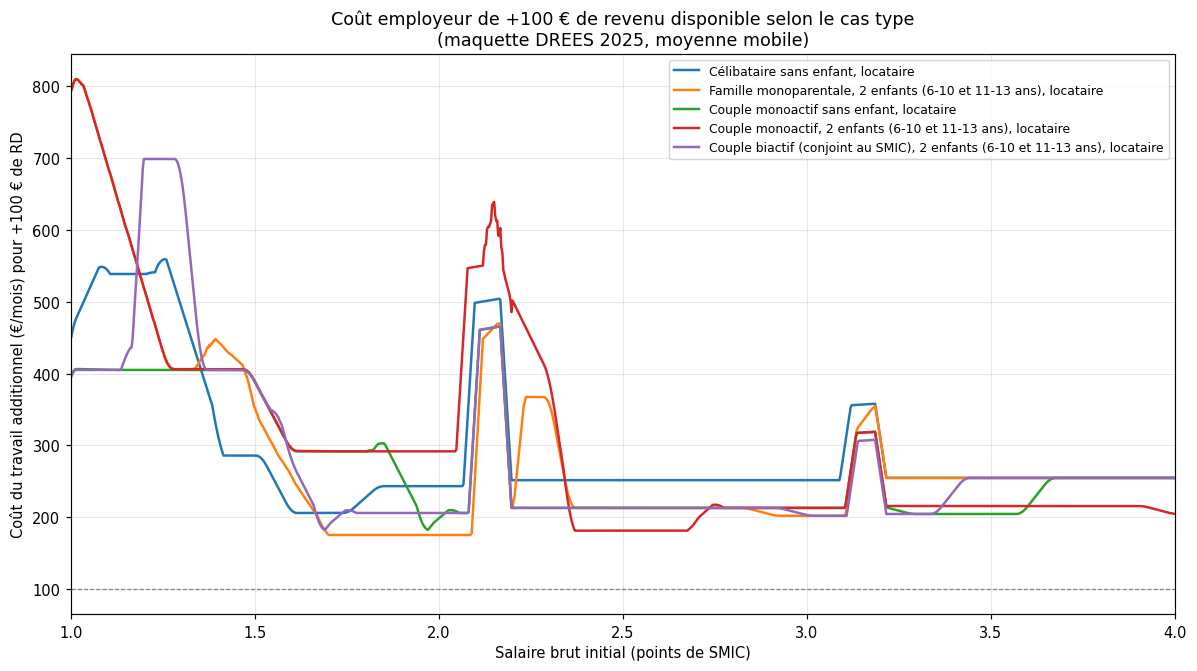

In [8]:
# maquette DREES 2025 ; le conjoint du couple biactif est recalé sur le SMIC 2025
bareme_2025 = load_bareme(2025)
CAS_TYPES_2025 = dict(CAS_TYPES)
CAS_TYPES_2025["couple_biactif_smic_2enf"] = dc_replace(
    CAS_TYPES["couple_biactif_smic_2enf"], sal_brut_conjoint=bareme_2025["smic_b"],
    label="Couple biactif (conjoint au SMIC), 2 enfants (6-10 et 11-13 ans), locataire")

resultats = {}
for cle, ct in CAS_TYPES_2025.items():
    d_ = simulate(ct, bareme_2025, brut_max=4.5, pas=5.0)
    resultats[cle] = decompose_plus100(d_, delta_rd=100.0)

# les 5 principaux cas types (les autres restent calculés dans `resultats`
# pour les sections suivantes)
PRINCIPAUX = ["celibataire", "monoparent_2enf", "couple_monoactif_0enf",
              "couple_monoactif_2enf", "couple_biactif_smic_2enf"]

fig, ax = plt.subplots(figsize=(11.5, 6.5))
for cle in PRINCIPAUX:
    dec = resultats[cle]
    # lissage sur la courbe complète puis découpe (pas de biais au bord gauche)
    zl = dec.dropna(subset=["check"]).copy()
    zl["lisse"] = zl["delta_cout_travail"].rolling(11, center=True, min_periods=1).mean()
    z = zl[(zl["pts_smic"] >= 1.0) & (zl["pts_smic"] <= 4.0)]
    ax.plot(z["pts_smic"], z["lisse"], lw=1.7, label=CAS_TYPES_2025[cle].label)
ax.axhline(100, ls="--", color="grey", lw=0.8)
ax.set_xlabel("Salaire brut initial (points de SMIC)")
ax.set_ylabel("Coût du travail additionnel (€/mois) pour +100 € de RD")
ax.set_title("Coût employeur de +100 € de revenu disponible selon le cas type\n(maquette DREES 2025, moyenne mobile)")
ax.legend(fontsize=8.5); ax.set_xlim(1, 4)
plt.tight_layout(); plt.show()

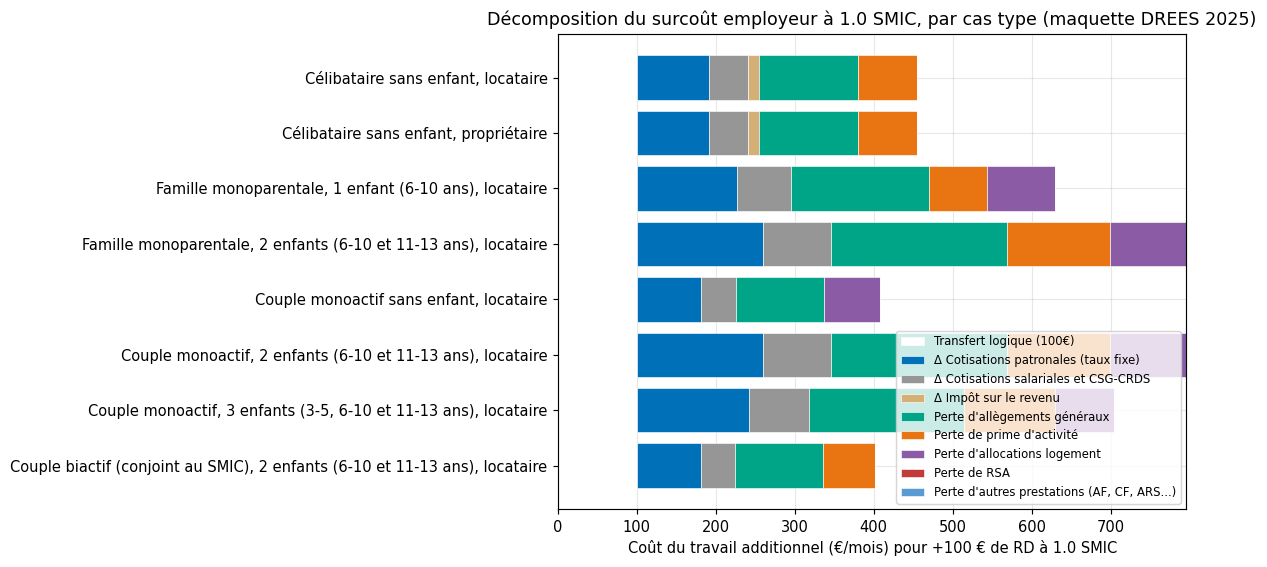

,Cas type,Transfert logique (100€),Δ Cotisations patronales (taux fixe),Δ Cotisations salariales et CSG-CRDS,Δ Impôt sur le revenu,Perte d'allègements généraux,Perte de prime d'activité,Perte d'allocations logement,Perte de RSA,"Perte d'autres prestations (AF, CF, ARS...)",Coût total
0,"Célibataire sans enfant, locataire",100.0,91.7,49.4,13.1,126.3,74.6,-0.0,-0.0,-0.0,455.1
1,"Célibataire sans enfant, propriétaire",100.0,91.7,49.4,13.1,126.3,74.6,-0.0,-0.0,-0.0,455.1
2,"Famille monoparentale, 1 enfant (6-10 ans), lo...",100.0,126.7,68.3,0.0,175.1,73.5,86.0,-0.0,-0.0,629.6
3,"Famille monoparentale, 2 enfants (6-10 et 11-1...",100.0,160.2,86.3,0.0,221.7,130.6,97.3,-0.0,-0.0,796.1
4,"Couple monoactif sans enfant, locataire",100.0,81.3,43.8,0.0,111.8,-4.5,71.0,-0.0,-0.0,403.5
5,"Couple monoactif, 2 enfants (6-10 et 11-13 ans...",100.0,160.2,86.3,0.0,221.7,130.6,97.3,-0.0,-0.0,796.1
6,"Couple monoactif, 3 enfants (3-5, 6-10 et 11-1...",100.0,141.8,76.4,0.0,196.1,115.6,74.7,-0.0,-0.0,704.6
7,"Couple biactif (conjoint au SMIC), 2 enfants (...",100.0,81.0,43.7,0.0,111.4,65.9,-0.0,-0.0,-0.0,402.1


In [9]:
# Décomposition comparée au voisinage du SMIC (salarié à 1,0 SMIC)
REF = 1.0
bandes = ["transfert", "delta_cot_pat", "delta_cot_sal", "delta_ir", "delta_perte_exo",
          "delta_perte_pa", "delta_perte_al", "delta_perte_rsa", "delta_perte_pf"]
lignes = []
for cle, dec in resultats.items():
    i = (dec["pts_smic"] - REF).abs().idxmin()
    lignes.append([CAS_TYPES_2025[cle].label] + [dec.loc[i, c] for c in bandes]
                  + [dec.loc[i, "delta_cout_travail"]])
comp = pd.DataFrame(lignes, columns=["Cas type"] + [LABELS_FR[c] for c in bandes] + ["Coût total"])

fig, ax = plt.subplots(figsize=(11.5, 5.5))
gauche = np.zeros(len(comp))
for c in bandes:
    lab = LABELS_FR[c]
    vals = np.clip(comp[lab].to_numpy(dtype=float), 0, None)
    ax.barh(comp["Cas type"], vals, left=gauche, color=COULEURS[lab],
            edgecolor="white", lw=0.4, label=lab)
    gauche += vals
ax.set_xlabel(f"Coût du travail additionnel (€/mois) pour +100 € de RD à {REF:.1f} SMIC")
ax.set_title(f"Décomposition du surcoût employeur à {REF:.1f} SMIC, par cas type (maquette DREES 2025)")
ax.invert_yaxis(); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

comp.round(1)

## 5. Célibataire sans enfant, propriétaire : évolution 2023 → 2026

Comparaison du coût employeur de +100 € de revenu disponible pour le **célibataire sans enfant
propriétaire** (pas d'APL ni de prestations familiales : la progressivité vient uniquement des
cotisations, des allègements, de la prime d'activité et de l'IR), sous cinq barèmes :

| Barème | Source |
|---|---|
| 2023, 2024, 2025 | maquettes DREES (`Maquette_cas_types_20xx.xls`) |
| **2026 (1er janvier)** | `MFrance1erjanvier2026.R` : SMIC 1 823,03 €, PASS 4 005 €, IR 2026 (décote 897 €/45,25 %), PA inchangée (633,21 € ; bonif max 184,27 € ; rampe 709,18 → 1 442,40 €), **réforme des allègements** (barème unique jusqu'à 3 SMIC : 38,21 % × (0,5·(3·SMIC/brut − 1))^1,75 + 2 %) |
| **2026 (1er juin : hausse du SMIC + gel du barème)** | `MFrance1eravril26.R` : trois différences fiscalo-sociales avec le 1er janvier — (1) SMIC porté à **1 867,02 €**, (2) PA revalorisée (638,28 € ; bonif max **240,63 €** ; rampe étendue jusqu'à **1 658,76 €**), (3) barème des allègements **gelé** (référence maintenue à 3 × 1 823,03 €). Barème IR gelé. Les prestations intègrent la revalorisation du **1er avril 2026** (+0,8 %, décret n°2026-220) : RSA 651,69 €, BMAF 478,16 € (AF 152,25 €, CF, PAJE, ARS 2026), ASF +0,9 %, AAH, ASS ; R0 des APL gelé ; majoration d'âge des AF à partir de 18 ans (réforme du 1er mars 2026). Dans les deux barèmes 2026 : L+C et PO des APL +1,04 % (revalorisation d'octobre 2025) et seuils de modulation des AF +1,8 % (1er janvier 2026). |

NB : contrairement au modèle France « maison », le modèle Edifis retranche un **forfait logement**
de la base ressources de la PA pour un propriétaire (77,58 €/mois), d'où une PA plus faible d'environ
ce montant. L'axe des abscisses est exprimé en points du **SMIC courant de chaque scénario**.

Les pics locaux visibles dans les tableaux sont des **effets de seuil réels** des barèmes : sortie
« en falaise » du bandeau maladie (2,5 SMIC jusqu'en 2024, seuil gelé en euros en 2025, fusionné
dans le barème unique en 2026), seuil de versement de la PA, entrée dans l'IR.

In [10]:
baremes_annees = {
    "2023": load_bareme(2023),
    "2024": load_bareme(2024),
    "2025": load_bareme(2025),
    "2026 (1er janvier)": build_bareme_2026("janvier"),
    "2026 (1er juin : SMIC +2,4% + gel du barème)": build_bareme_2026("juin_gel"),
}
couleurs_annees = {"2023": "#B0B0B0", "2024": "#7F7F7F", "2025": "#0071B9",
                   "2026 (1er janvier)": "#E87511",
                   "2026 (1er juin : SMIC +2,4% + gel du barème)": "#C13B3B"}

cas_prop = CAS_TYPES["celibataire_proprietaire"]
decomp_annees = {}
for nom, bar in baremes_annees.items():
    d_ = simulate(cas_prop, bar, brut_max=4.5, pas=5.0)
    decomp_annees[nom] = decompose_plus100(d_, delta_rd=100.0)
    print(f"{nom:48s} SMIC brut = {bar['smic_b']:8.2f} €  |  SMIC net = {bar['smic_n']:8.2f} €")

2023                                             SMIC brut =  1747.24 €  |  SMIC net =  1383.07 €
2024                                             SMIC brut =  1766.92 €  |  SMIC net =  1398.70 €
2025                                             SMIC brut =  1801.80 €  |  SMIC net =  1426.30 €
2026 (1er janvier)                               SMIC brut =  1823.03 €  |  SMIC net =  1443.11 €
2026 (1er juin : SMIC +2,4% + gel du barème)     SMIC brut =  1867.02 €  |  SMIC net =  1477.93 €


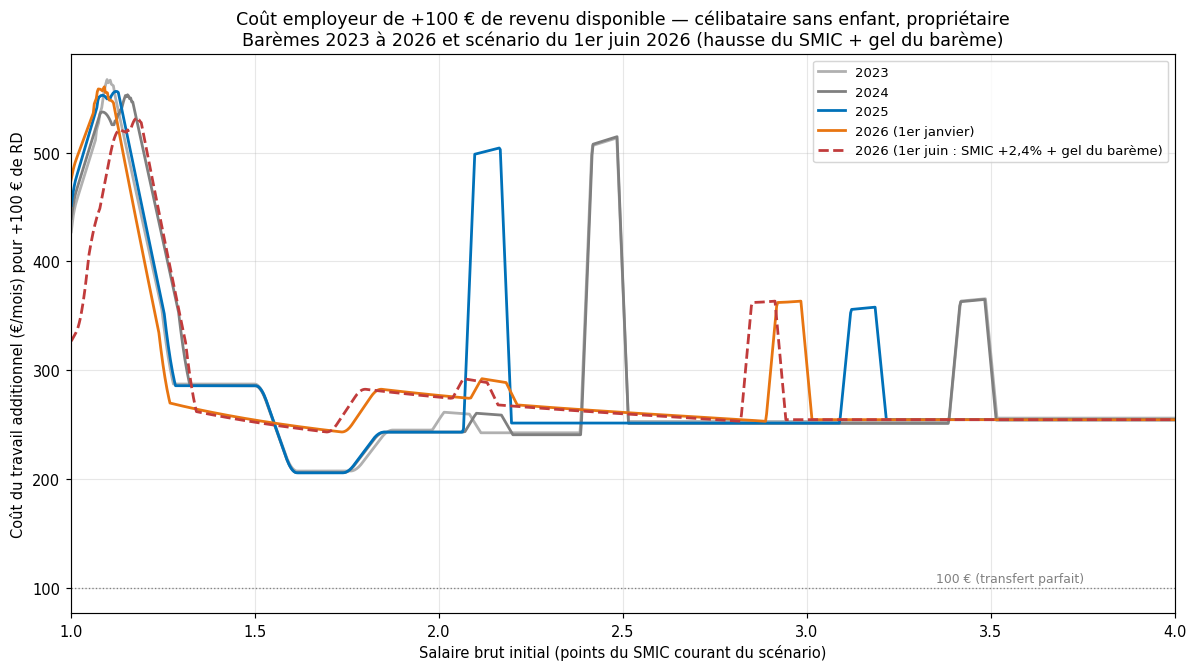

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))
for nom, dec in decomp_annees.items():
    # lissage sur la courbe complète puis découpe (pas de biais au bord gauche)
    zl = dec.dropna(subset=["check"]).copy()
    zl["lisse"] = zl["delta_cout_travail"].rolling(11, center=True, min_periods=1).mean()
    z = zl[(zl["pts_smic"] >= 1.0) & (zl["pts_smic"] <= 4.0)]
    style = "--" if "juin" in nom else "-"
    ax.plot(z["pts_smic"], z["lisse"], lw=1.9, ls=style, color=couleurs_annees[nom], label=nom)
ax.axhline(100, ls=":", color="grey", lw=0.9)
ax.annotate("100 € (transfert parfait)", xy=(3.35, 106), color="grey", fontsize=8.5)
ax.set_xlabel("Salaire brut initial (points du SMIC courant du scénario)")
ax.set_ylabel("Coût du travail additionnel (€/mois) pour +100 € de RD")
ax.set_title("Coût employeur de +100 € de revenu disponible — célibataire sans enfant, propriétaire\nBarèmes 2023 à 2026 et scénario du 1er juin 2026 (hausse du SMIC + gel du barème)")
ax.legend(fontsize=9); ax.set_xlim(1, 4)
plt.tight_layout(); plt.show()

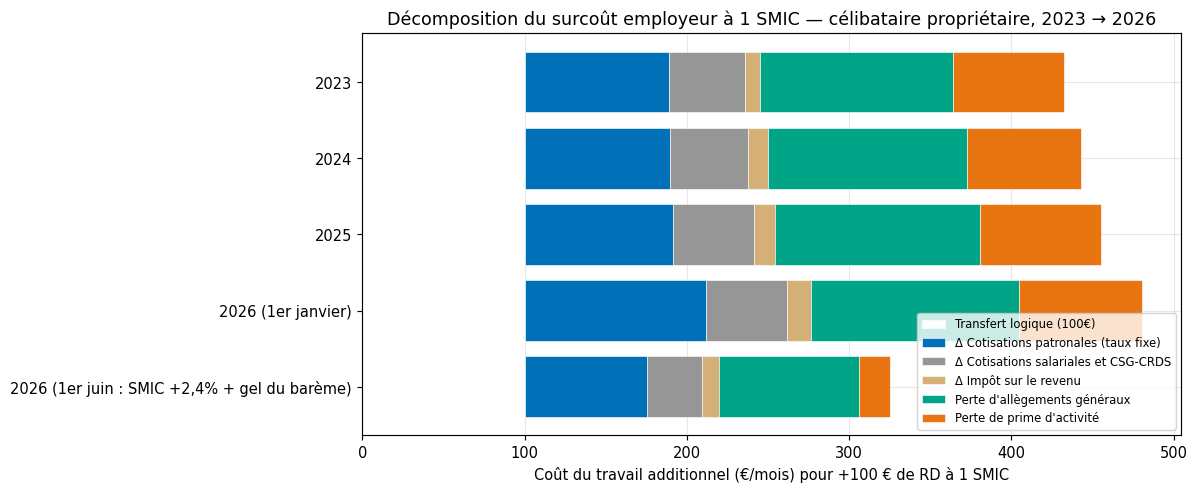

,Barème,Transfert logique (100€),Δ Cotisations patronales (taux fixe),Δ Cotisations salariales et CSG-CRDS,Δ Impôt sur le revenu,Perte d'allègements généraux,Perte de prime d'activité,Perte d'allocations logement,Perte de RSA,"Perte d'autres prestations (AF, CF, ARS...)",Coût total
0,2023,100.0,89.2,46.8,9.2,118.9,68.5,-0.0,-0.0,-0.0,432.6
1,2024,100.0,89.4,48.1,12.3,122.8,70.5,-0.0,-0.0,-0.0,443.1
2,2025,100.0,91.7,49.4,13.1,126.3,74.6,-0.0,-0.0,-0.0,455.1
3,2026 (1er janvier),100.0,111.8,50.2,14.4,128.3,76.1,-0.0,-0.0,-0.0,480.8
4,"2026 (1er juin : SMIC +2,4% + gel du barème)",100.0,75.7,33.9,9.9,86.6,19.0,-0.0,-0.0,-0.0,325.2


In [12]:
# Décomposition comparée au SMIC (1,0 SMIC courant de chaque scénario)
bandes = ["transfert", "delta_cot_pat", "delta_cot_sal", "delta_ir", "delta_perte_exo",
          "delta_perte_pa", "delta_perte_al", "delta_perte_rsa", "delta_perte_pf"]
lignes = []
for nom, dec in decomp_annees.items():
    i = (dec["pts_smic"] - 1.0).abs().idxmin()
    lignes.append([nom] + [dec.loc[i, c] for c in bandes] + [dec.loc[i, "delta_cout_travail"]])
comp_annees = pd.DataFrame(lignes, columns=["Barème"] + [LABELS_FR[c] for c in bandes] + ["Coût total"])

fig, ax = plt.subplots(figsize=(11.5, 4.8))
gauche = np.zeros(len(comp_annees))
for c in bandes:
    lab = LABELS_FR[c]
    vals = np.clip(comp_annees[lab].to_numpy(dtype=float), 0, None)
    if vals.sum() < 0.5 and c not in ("transfert",):
        continue
    ax.barh(comp_annees["Barème"], vals, left=gauche, color=COULEURS[lab],
            edgecolor="white", lw=0.4, label=lab)
    gauche += vals
ax.set_xlabel("Coût du travail additionnel (€/mois) pour +100 € de RD à 1 SMIC")
ax.set_title("Décomposition du surcoût employeur à 1 SMIC — célibataire propriétaire, 2023 → 2026")
ax.invert_yaxis(); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

comp_annees.round(1)

In [13]:
# Tableau récapitulatif aux points clés, par barème
points = [1.0, 1.2, 1.5, 2.0, 2.5, 3.0]
blocs = []
for nom, dec in decomp_annees.items():
    idx = [(dec["pts_smic"] - p).abs().idxmin() for p in points]
    t = dec.loc[idx, ["pts_smic", "salaire_brut", "rev_disp", "delta_cout_travail",
                      "delta_perte_exo", "delta_perte_pa", "delta_ir"]].round(1)
    t.insert(0, "Barème", nom)
    blocs.append(t)
recap = pd.concat(blocs, ignore_index=True)
recap.columns = ["Barème", "SMIC", "Brut (€)", "RD (€)", "Coût +100€ RD",
                 "dont perte allèg.", "dont perte PA", "dont Δ IR"]
recap["SMIC"] = recap["SMIC"].round(1)

with pd.ExcelWriter(Path("sorties") / "comparaison_2023_2026_celibataire_proprietaire.xlsx") as xl:
    recap.to_excel(xl, sheet_name="points_cles", index=False)
    comp_annees.round(2).to_excel(xl, sheet_name="decomposition_1smic", index=False)
    for nom, dec in decomp_annees.items():
        feuille = nom[:28].replace(":", "-").replace("/", "-")
        dec.round(2).to_excel(xl, sheet_name=feuille, index=False)
print("Export : sorties/comparaison_2023_2026_celibataire_proprietaire.xlsx")
recap.pivot(index="SMIC", columns="Barème", values="Coût +100€ RD").round(0)

Export : sorties/comparaison_2023_2026_celibataire_proprietaire.xlsx


Barème,2023,2024,2025,2026 (1er janvier),"2026 (1er juin : SMIC +2,4% + gel du barème)"
SMIC,,,,,
1.0,433.0,443.0,455.0,481.0,325.0
1.2,431.0,498.0,442.0,398.0,514.0
1.5,287.0,286.0,286.0,254.0,252.0
2.0,262.0,243.0,243.0,277.0,275.0
2.5,253.0,516.0,252.0,261.0,260.0
3.0,253.0,251.0,252.0,255.0,255.0


## 6. Widget interactif : décomposition par cas type, avec les effets induits de la prime d'activité

**Barème utilisé : le dernier en date — 1er juin 2026** (SMIC 1 867,02 €, PA réformée d'avril,
barème d'allègements gelé à 3 × 1 823,03 €, prestations revalorisées au 1er avril).

Méthode de la note « Les aides aux ménages constituent un frein à la progression salariale » :
on refait la décomposition **en l'absence du mécanisme choisi** (contrefactuel). Les bandes
bleues/grises donnent la situation « de droit commun » (telle qu'elle serait sans ce mécanisme) ;
s'y ajoutent son **effet direct** et ses **effets induits de cascade**, ventilés par composante
réceptrice : parce qu'il faut compenser le mécanisme, le brut doit monter davantage, ce qui
renchérit à son tour cotisations, allègements, IR et pertes de prestations.

**Pourquoi les allègements n'ont-ils pas d'effets induits propres ?** La cascade naît des mécanismes
situés **entre le salaire net et le revenu disponible** (PA, IR, APL, RSA) : ce sont eux qui obligent
à augmenter davantage le brut. Les allègements sont en aval, côté coût : ils n'exigent aucun brut
supplémentaire (effet induit ≈ 0 quand on les sélectionne), mais ils **amplifient** la cascade des
autres — la bande « effet induit sur les allègements » est l'une des plus grosses quand on
sélectionne la PA ou l'IR. Le widget permet de le vérifier.

*Menus actifs quand le notebook tourne dans Jupyter ; le réglage « Lissage » applique une moyenne
mobile qui gomme les pics d'effets de seuil (falaise du seuil de versement de la PA, PASS...).*

Barème des widgets : législation au 1er juin 2026 (SMIC 1 867,02 €, PA d'avril, allègements gelés)
SMIC net au 1er juin 2026 = 1,477.93 €


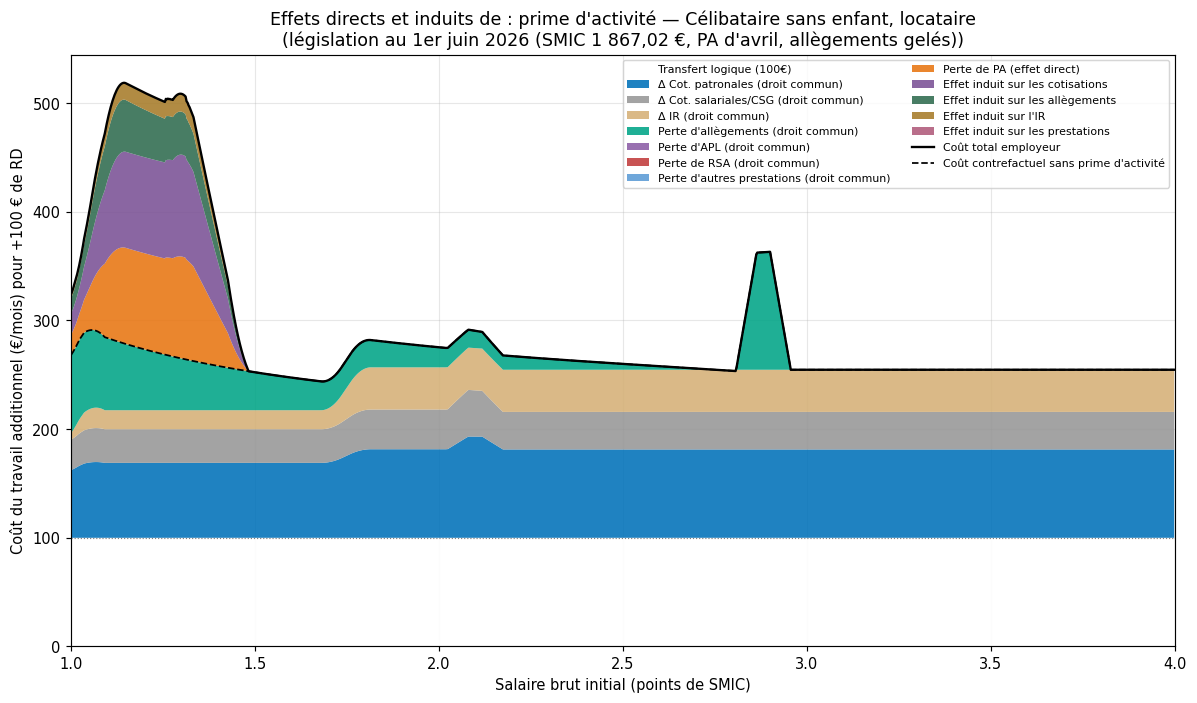

À 1,15 SMIC : coût total 518 € = droit commun sans prime d'activité 278 € + effet direct 88 € + effets induits 152 €


In [14]:
# ── Barème des widgets : 1er JUIN 2026 (dernier modèle) ─────────────────────
bareme_juin = build_bareme_2026("juin_gel")
LABEL_JUIN = "législation au 1er juin 2026 (SMIC 1 867,02 €, PA d'avril, allègements gelés)"
CAS_TYPES_JUIN = dict(CAS_TYPES)
CAS_TYPES_JUIN["couple_biactif_smic_2enf"] = dc_replace(
    CAS_TYPES["couple_biactif_smic_2enf"], sal_brut_conjoint=bareme_juin["smic_b"],
    label="Couple biactif (conjoint au SMIC du 1er juin 2026), 2 enfants (6-10 et 11-13 ans), locataire")
print(f"Barème des widgets : {LABEL_JUIN}")
print(f"SMIC net au 1er juin 2026 = {bareme_juin['smic_n']:,.2f} €")

MECA_LIBELLES = {"pa": "prime d'activité", "ir": "impôt sur le revenu",
                 "apl": "APL", "rsa": "RSA", "allegements": "allègements généraux"}
MECA_DIRECTE = {"pa": "Perte de PA (effet direct)", "ir": "Δ IR (effet direct)",
                "apl": "Perte d'APL (effet direct)", "rsa": "Perte de RSA (effet direct)",
                "allegements": "Perte d'allègements (effet direct)"}

# bandes « droit commun » (contrefactuel sans le mécanisme choisi)
BANDES_SANS = [
    ("transfert",            "Transfert logique (100€)",              "#FFFFFF"),
    ("delta_cot_pat_sans",   "Δ Cot. patronales (droit commun)",      "#0071B9"),
    ("delta_cot_sal_sans",   "Δ Cot. salariales/CSG (droit commun)",  "#969696"),
    ("delta_ir_sans",        "Δ IR (droit commun)",                   "#D5B076"),
    ("delta_perte_exo_sans", "Perte d'allègements (droit commun)",    "#00A486"),
    ("delta_perte_al_sans",  "Perte d'APL (droit commun)",            "#8B5CA5"),
    ("delta_perte_rsa_sans", "Perte de RSA (droit commun)",           "#C13B3B"),
    ("delta_perte_pf_sans",  "Perte d'autres prestations (droit commun)", "#5B9BD5"),
]
# effets induits ventilés par composante réceptrice (avec - sans, hors effet direct)
INDUITS = [
    (["delta_cot_pat", "delta_cot_sal"], "Effet induit sur les cotisations",   "#7A5195"),
    (["delta_perte_exo"],                "Effet induit sur les allègements",   "#2F6B4F"),
    (["delta_ir"],                       "Effet induit sur l'IR",              "#A67B29"),
    (["delta_perte_al", "delta_perte_rsa", "delta_perte_pf", "delta_perte_pa"],
                                         "Effet induit sur les prestations",   "#B05A7A"),
]
LISSAGES = {"Aucun": 1, "Léger (±50 €)": 21, "Fort (±150 €)": 61}

_cascade_cache = {}
def get_cascade(cle_cas, mecanisme):
    if (cle_cas, mecanisme) not in _cascade_cache:
        _cascade_cache[(cle_cas, mecanisme)] = decompose_cascade(
            CAS_TYPES_JUIN[cle_cas], bareme_juin, mecanisme)
    return _cascade_cache[(cle_cas, mecanisme)]

def plot_cascade(cle_cas, mecanisme="pa", lissage="Léger (±50 €)"):
    d = get_cascade(cle_cas, mecanisme)
    cle_directe = {"pa": "delta_perte_pa", "apl": "delta_perte_al", "ir": "delta_ir",
                   "rsa": "delta_perte_rsa", "allegements": "delta_perte_exo"}[mecanisme]
    z = d.dropna(subset=["check"]).copy()
    w = LISSAGES[lissage]
    _mask = (z["pts_smic"] >= 1.0) & (z["pts_smic"] <= 4.0)
    # lissage calculé sur la courbe complète PUIS découpé : évite le biais de
    # bord qui gonflait artificiellement le point de départ à 1 SMIC
    liss = lambda s: s.rolling(w, center=True, min_periods=1).mean()[_mask]
    z_x = z["pts_smic"][_mask]

    series, labels, colors = [], [], []
    for c, lab, col in BANDES_SANS:
        if c == cle_directe + "_sans":      # la bande du mécanisme retiré est nulle
            continue
        series.append(np.clip(liss(z[c]), 0, None)); labels.append(lab); colors.append(col)
    series.append(np.clip(liss(z["effet_direct"]), 0, None))
    labels.append(MECA_DIRECTE[mecanisme]); colors.append("#E87511")
    for cols_i, lab, col in INDUITS:
        cols_ok = [c for c in cols_i if c != cle_directe]
        v = (sum(z[c] - z[c + "_sans"] for c in cols_ok) if cols_ok
             else pd.Series(0.0, index=z.index))
        series.append(np.clip(liss(v), 0, None)); labels.append(lab); colors.append(col)

    fig, ax = plt.subplots(figsize=(11.5, 6.8))
    ax.stackplot(z_x, series, labels=labels, colors=colors, alpha=0.88)
    ax.plot(z_x, liss(z["delta_cout_travail"]), color="black", lw=1.6,
            label="Coût total employeur")
    ax.plot(z_x, liss(z["cout_sans"]), color="black", lw=1.2, ls="--",
            label=f"Coût contrefactuel sans {MECA_LIBELLES[mecanisme]}")
    ax.axhline(100, ls=":", color="grey", lw=0.8)
    ax.set_xlim(1, 4)
    ax.set_xlabel("Salaire brut initial (points de SMIC)")
    ax.set_ylabel("Coût du travail additionnel (€/mois) pour +100 € de RD")
    ax.set_title(f"Effets directs et induits de : {MECA_LIBELLES[mecanisme]} — "
                 f"{CAS_TYPES_JUIN[cle_cas].label}\n({LABEL_JUIN})")
    ax.legend(loc="upper right", fontsize=7.5, ncol=2)
    plt.tight_layout(); plt.show()

    i = (d["pts_smic"] - 1.15).abs().idxmin()
    r = d.loc[i]
    print(f"À 1,15 SMIC : coût total {r['delta_cout_travail']:.0f} € = "
          f"droit commun sans {MECA_LIBELLES[mecanisme]} {r['cout_sans']:.0f} € "
          f"+ effet direct {r['effet_direct']:.0f} € "
          f"+ effets induits {r['effet_induit']:.0f} €")

plot_cascade("celibataire", "pa")

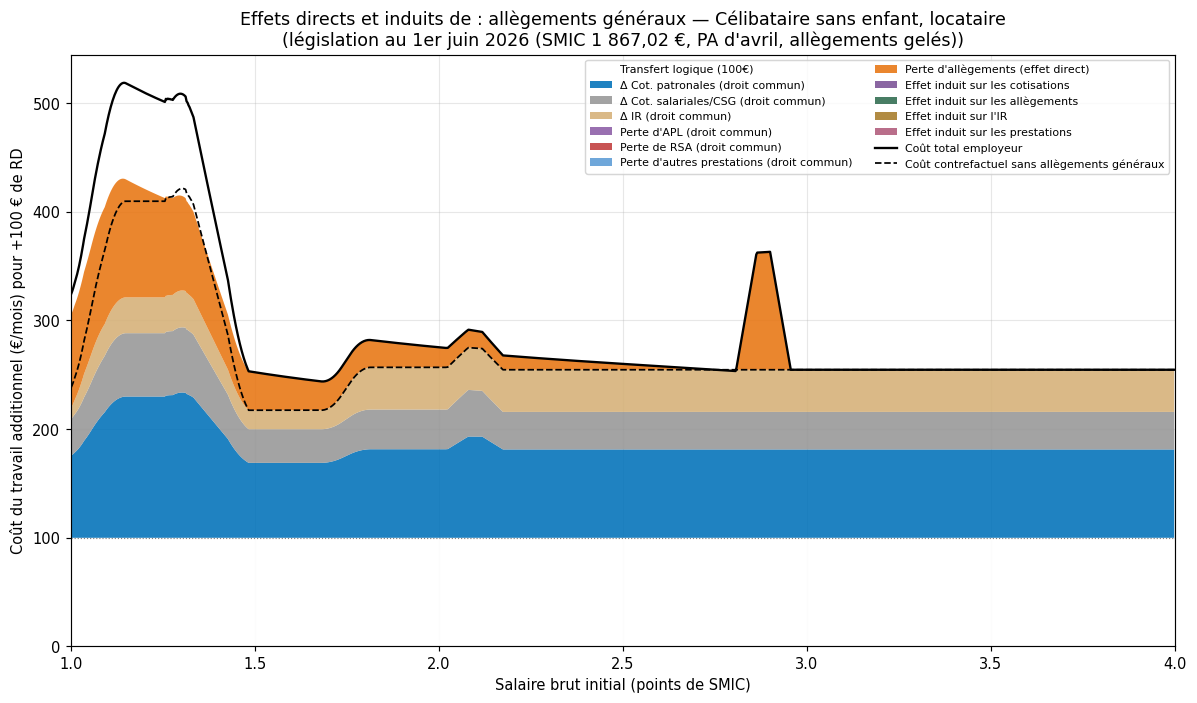

À 1,15 SMIC : coût total 518 € = droit commun sans allègements généraux 410 € + effet direct 109 € + effets induits 0 €


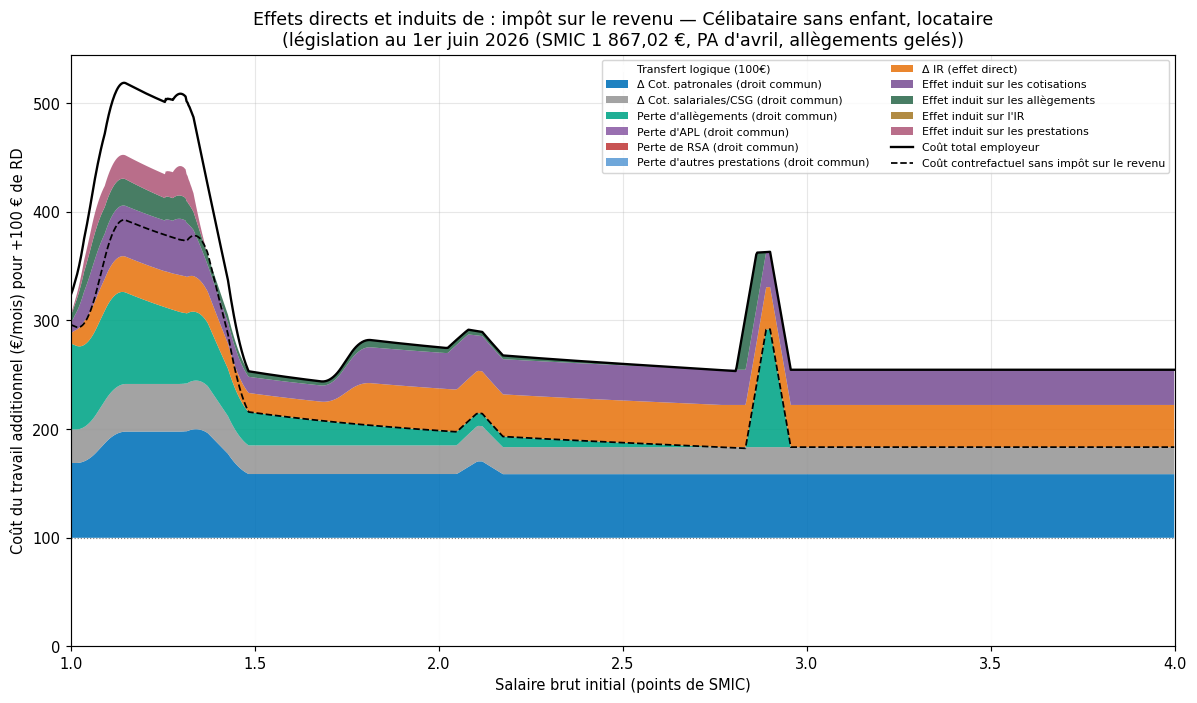

À 1,15 SMIC : coût total 518 € = droit commun sans impôt sur le revenu 392 € + effet direct 33 € + effets induits 93 €


In [15]:
# Contre-exemple pédagogique : les allègements n'engendrent AUCUN effet induit
# (ils ne modifient pas le revenu disponible, donc pas le brut nécessaire) ;
# et l'IR, lui, en engendre bien.
plot_cascade("celibataire", "allegements", "Léger (±50 €)")
plot_cascade("celibataire", "ir", "Léger (±50 €)")

> ⚠️ **Les widgets ci-dessous nécessitent d'exécuter les cellules** (Kernel → *Restart & Run All*).
> L'état interactif n'est pas conservé dans le fichier sauvegardé : à l'ouverture, la cellule peut
> apparaître vide tant qu'elle n'a pas été relancée.

In [16]:
import ipywidgets as widgets

widgets.interact(
    plot_cascade,
    cle_cas=widgets.Dropdown(options=[(ct.label, cle) for cle, ct in CAS_TYPES_JUIN.items()],
                             value="celibataire", description="Cas type :",
                             layout=widgets.Layout(width="640px"),
                             style={"description_width": "90px"}),
    mecanisme=widgets.Dropdown(options=[(lib.capitalize(), m) for m, lib in MECA_LIBELLES.items()],
                               value="pa", description="Mécanisme :",
                               style={"description_width": "90px"}),
    lissage=widgets.SelectionSlider(options=list(LISSAGES), value="Léger (±50 €)",
                                    description="Lissage :",
                                    style={"description_width": "90px"}));

interactive(children=(Dropdown(description='Cas type :', layout=Layout(width='640px'), options=(('Célibataire …

## 7. Widget de simulation : que se passe-t-il si on retire un mécanisme ?

**Barème utilisé : 1er juin 2026** (dernier modèle, comme la section 6).

Cocher les mécanismes à **retirer** (allègements généraux, IR, APL, prime d'activité, RSA) : le
graphique montre la décomposition du coût marginal de +100 € de RD dans ce monde contrefactuel,
comparée au coût du système actuel (ligne grise).

⚠️ Deux effets à ne pas confondre : retirer les **allègements** *réduit le coût marginal* de la
progression salariale (plus de pente à rembourser) mais *augmente fortement le niveau* du coût du
travail (affiché sous le graphique) ; retirer la **PA** réduit le coût marginal mais ampute le revenu
disponible du salarié (niveau affiché également).

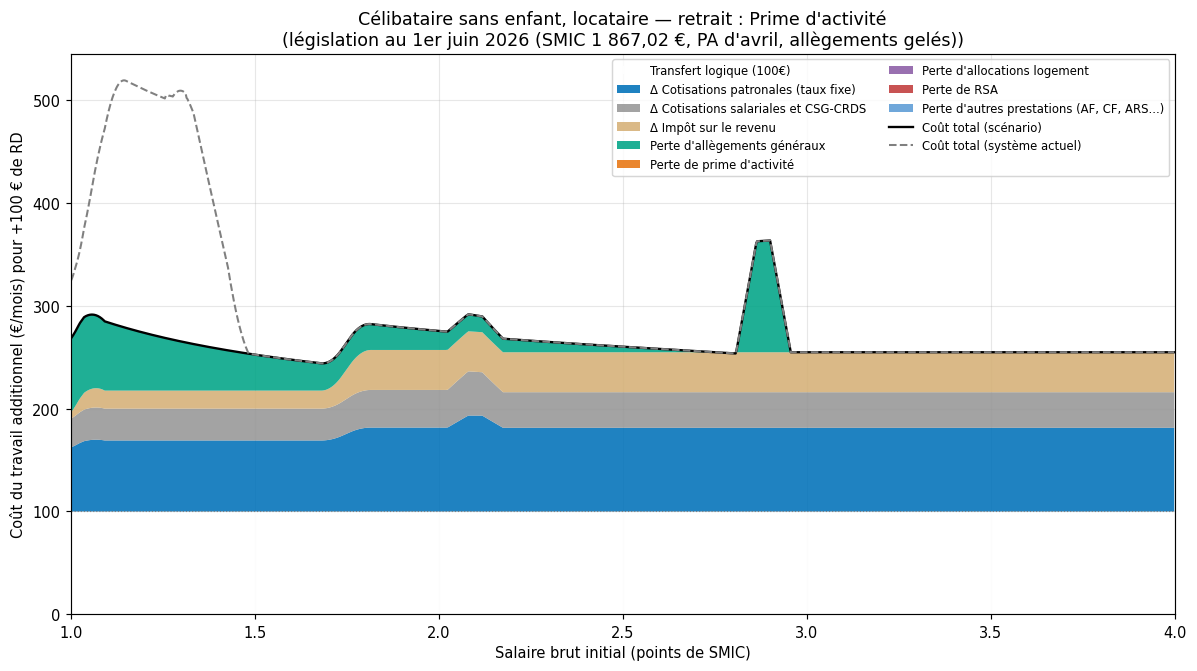

Niveaux à 1 SMIC — coût du travail : 2023 € (système actuel : 2023 €) | revenu disponible : 1476 € (système actuel : 1715 €)
 SMIC  Coût actuel (€)  Coût scénario (€)
  1.0            325.0              270.0
  1.2            510.0              273.0
  1.5            252.0              252.0
  2.0            275.0              275.0


In [17]:
ORDRE_BANDES_SIMPLE = ["transfert", "delta_cot_pat", "delta_cot_sal", "delta_ir",
                       "delta_perte_exo", "delta_perte_pa", "delta_perte_al",
                       "delta_perte_rsa", "delta_perte_pf"]
_ref_cache = {}

def plot_retrait(cle_cas, retraits, lissage="Léger (±50 €)"):
    retraits = frozenset(retraits)
    if cle_cas not in _ref_cache:
        _ref_cache[cle_cas] = decompose_plus100(
            simulate(CAS_TYPES_JUIN[cle_cas], bareme_juin, brut_max=4.5, pas=5.0))
    ref = _ref_cache[cle_cas]
    df_s = simulate(CAS_TYPES_JUIN[cle_cas], bareme_juin, brut_max=4.5, pas=5.0, sans=retraits)
    dec = decompose_plus100(df_s)
    z = dec.dropna(subset=["check"]).copy()
    zr = ref.dropna(subset=["check"]).copy()
    w = LISSAGES[lissage]
    _mz = (z["pts_smic"] >= 1.0) & (z["pts_smic"] <= 4.0)
    _mr = (zr["pts_smic"] >= 1.0) & (zr["pts_smic"] <= 4.0)
    # lissage sur la courbe complète puis découpe (pas de biais de bord)
    liss = lambda s, m: s.rolling(w, center=True, min_periods=1).mean()[m]

    fig, ax = plt.subplots(figsize=(11.5, 6.5))
    ax.stackplot(z["pts_smic"][_mz],
                 [np.clip(liss(z[c], _mz), 0, None) for c in ORDRE_BANDES_SIMPLE],
                 labels=[LABELS_FR[c] for c in ORDRE_BANDES_SIMPLE],
                 colors=[COULEURS[LABELS_FR[c]] for c in ORDRE_BANDES_SIMPLE], alpha=0.88)
    ax.plot(z["pts_smic"][_mz], liss(z["delta_cout_travail"], _mz), color="black", lw=1.6,
            label="Coût total (scénario)")
    ax.plot(zr["pts_smic"][_mr], liss(zr["delta_cout_travail"], _mr), color="grey", lw=1.4, ls="--",
            label="Coût total (système actuel)")
    ax.axhline(100, ls=":", color="grey", lw=0.8)
    ax.set_xlim(1, 4)
    titre_retraits = ", ".join(MECANISMES[m] for m in sorted(retraits)) or "aucun retrait"
    ax.set_xlabel("Salaire brut initial (points de SMIC)")
    ax.set_ylabel("Coût du travail additionnel (€/mois) pour +100 € de RD")
    ax.set_title(f"{CAS_TYPES_JUIN[cle_cas].label} — retrait : {titre_retraits}\n({LABEL_JUIN})")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

    # effets de NIVEAU au SMIC (à distinguer du coût marginal)
    i = (df_s["pts_smic"] - 1.0).abs().idxmin()
    base = _ref_cache[cle_cas]
    j = (base["pts_smic"] - 1.0).abs().idxmin()
    print(f"Niveaux à 1 SMIC — coût du travail : {df_s.loc[i,'cout_travail']:.0f} € "
          f"(système actuel : {base.loc[j,'cout_travail']:.0f} €) | "
          f"revenu disponible : {df_s.loc[i,'rev_disp']:.0f} € "
          f"(système actuel : {base.loc[j,'rev_disp']:.0f} €)")
    pts_aff = [1.0, 1.2, 1.5, 2.0]
    lignes = []
    for p_ in pts_aff:
        k = (dec["pts_smic"] - p_).abs().idxmin()
        kr = (ref["pts_smic"] - p_).abs().idxmin()
        lignes.append([p_, ref.loc[kr, "delta_cout_travail"], dec.loc[k, "delta_cout_travail"]])
    t = pd.DataFrame(lignes, columns=["SMIC", "Coût actuel (€)", "Coût scénario (€)"])
    t[["Coût actuel (€)", "Coût scénario (€)"]] = t[["Coût actuel (€)", "Coût scénario (€)"]].round(0)
    print(t.to_string(index=False))

# exemple statique : retrait de la prime d'activité pour le célibataire
plot_retrait("celibataire", {"pa"})

In [18]:
import ipywidgets as widgets

def ui_retrait(cle_cas, allegements=False, ir=False, apl=False, pa=False, rsa=False,
               lissage="Léger (±50 €)"):
    retraits = {m for m, v in [("allegements", allegements), ("ir", ir),
                               ("apl", apl), ("pa", pa), ("rsa", rsa)] if v}
    plot_retrait(cle_cas, retraits, lissage)

widgets.interact(
    ui_retrait,
    cle_cas=widgets.Dropdown(options=[(ct.label, cle) for cle, ct in CAS_TYPES_JUIN.items()],
                             value="celibataire", description="Cas type :",
                             layout=widgets.Layout(width="640px"),
                             style={"description_width": "90px"}),
    allegements=widgets.Checkbox(value=False, description="Retirer les allègements généraux", indent=False),
    ir=widgets.Checkbox(value=False, description="Retirer l'impôt sur le revenu", indent=False),
    apl=widgets.Checkbox(value=False, description="Retirer les APL", indent=False),
    pa=widgets.Checkbox(value=False, description="Retirer la prime d'activité", indent=False),
    rsa=widgets.Checkbox(value=False, description="Retirer le RSA", indent=False),
    lissage=widgets.SelectionSlider(options=list(LISSAGES), value="Léger (±50 €)",
                                    description="Lissage :",
                                    style={"description_width": "90px"}));

interactive(children=(Dropdown(description='Cas type :', layout=Layout(width='640px'), options=(('Célibataire …

## 8. Scénarios alternatifs de barème d'allègements : visions Bozio-Wasmer et rapport du SMIC

Trois courbes de coût marginal (+100 € de revenu disponible, célibataire sans enfant),
en ne changeant **que** la formule des allègements généraux (tout le reste au barème du
1er juin 2026, bandeaux fusionnés dans le barème d'allègements dans les trois cas) :

| Scénario | Formule (≥ 50 salariés ; < 50 : taux à −0,4 pt) | Sortie |
|---|---|---|
| **Barème actuel (1er juin 2026)** | 0,3821 × (0,5 × (3 × 1 823,03/brut − 1))^1,75 + 0,02, référence gelée | 3 × SMIC de janvier |
| **Vision Bozio-Wasmer** | 0,3621 × (1/1,5) × (2,5 × SMIC/brut − 1) | 2,5 SMIC |
| **Vision rapport du SMIC** | 0,4021 × (2 × SMIC/brut − 1) | 2 SMIC |

Les deux visions alternatives sont indexées sur le SMIC courant (1 867,02 €), sans gel.

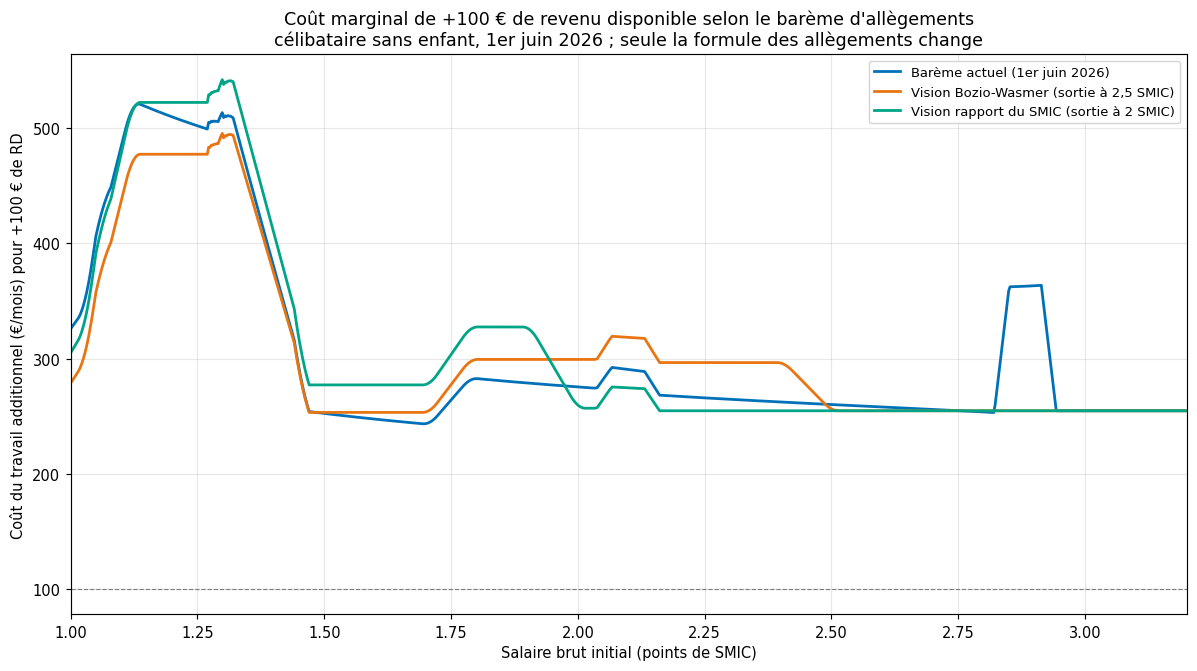

,Scénario,1.0 SMIC,1.15 SMIC,1.3 SMIC,1.5 SMIC,2.0 SMIC,2.5 SMIC
0,Barème actuel (1er juin 2026),325.0,518.0,495.0,252.0,275.0,260.0
1,"Vision Bozio-Wasmer (sortie à 2,5 SMIC)",278.0,477.0,477.0,253.0,299.0,255.0
2,Vision rapport du SMIC (sortie à 2 SMIC),304.0,522.0,522.0,277.0,257.0,255.0


In [19]:
from edifis_model import exo_fillon_generique

scenarios_exo = {
    "Barème actuel (1er juin 2026)": (bareme_juin, "#0071B9", "-"),
    "Vision Bozio-Wasmer (sortie à 2,5 SMIC)": (
        dict(bareme_juin, exo_custom=exo_fillon_generique(0.3621, 2.5)), "#E87511", "-"),
    "Vision rapport du SMIC (sortie à 2 SMIC)": (
        dict(bareme_juin, exo_custom=exo_fillon_generique(0.4021, 2.0)), "#00A486", "-"),
}

cas_sc = CAS_TYPES_JUIN["celibataire"]
decomp_sc = {nom: decompose_plus100(simulate(cas_sc, bar, brut_max=4.5, pas=5.0))
             for nom, (bar, _, _) in scenarios_exo.items()}

fig, ax = plt.subplots(figsize=(11.5, 6.5))
for nom, (bar, coul, style) in scenarios_exo.items():
    dec = decomp_sc[nom]
    zl = dec.dropna(subset=["check"]).copy()
    zl["lisse"] = zl["delta_cout_travail"].rolling(11, center=True, min_periods=1).mean()
    z = zl[(zl["pts_smic"] >= 1.0) & (zl["pts_smic"] <= 3.2)]
    ax.plot(z["pts_smic"], z["lisse"], lw=1.9, ls=style, color=coul, label=nom)
ax.axhline(100, ls="--", color="grey", lw=0.8)
ax.set_xlim(1, 3.2)
ax.set_xlabel("Salaire brut initial (points de SMIC)")
ax.set_ylabel("Coût du travail additionnel (€/mois) pour +100 € de RD")
ax.set_title("Coût marginal de +100 € de revenu disponible selon le barème d'allègements\n"
             "célibataire sans enfant, 1er juin 2026 ; seule la formule des allègements change")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(Path("sorties/figures_note") / "fig6_visions_allegements.png", dpi=150)
plt.show()

points = [1.0, 1.15, 1.3, 1.5, 2.0, 2.5]
lignes = []
for nom, dec in decomp_sc.items():
    idx = [(dec["pts_smic"] - p).abs().idxmin() for p in points]
    lignes.append([nom] + [round(dec.loc[i, "delta_cout_travail"], 0) for i in idx])
pd.DataFrame(lignes, columns=["Scénario"] + [f"{p} SMIC" for p in points])

## 9. Vérifications

- l'identité comptable de la décomposition est exacte pour tous les cas types (maquette 2025) ;
- le salaire net simulé au SMIC 2025 correspond au paramètre `smic_n` de la maquette DREES ;
- le SMIC net simulé au 1er janvier 2026 correspond au plafond de la rampe de bonification PA
  du code `MFrance1erjanvier2026.R` (1 442,40 €) ;
- à salaire nul, le RSA socle vaut le montant forfaitaire moins le forfait logement.

In [20]:
print(f"{'cas type':30s} {'max |check|':>12s} {'net au SMIC 2025':>17s}")
for cle, dec in resultats.items():
    ok = dec.dropna(subset=["check"])
    i = (dec["pts_smic"] - 1.0).abs().idxmin()
    print(f"{cle:30s} {ok['check'].abs().max():12.6f} {dec.loc[i, 'rev_act_net']:17.2f}")
print(f"\nParamètre smic_n de la maquette DREES 2025 = {bareme_2025['smic_n']:.2f} €  (écart lié au pas de l'échelle : ±{5*0.79:.1f} €)")

print(f"{'barème':48s} {'max |check|':>12s}")
for nom, dec in decomp_annees.items():
    ok = dec.dropna(subset=["check"])
    print(f"{nom:48s} {ok['check'].abs().max():12.6f}")
print(f"\nSMIC net simulé au 1er janvier 2026 : {baremes_annees['2026 (1er janvier)']['smic_n']:.2f} € "
      f"(plafond de la rampe de bonification PA dans MFrance1erjanvier2026.R : 1 442,40 €)")

celib = simulate(CAS_TYPES['celibataire'], bareme, brut_max=1.0, pas=100.0)
rsa0 = celib.loc[0, 'mont_RSA']
attendu = bareme['mont_forfaitaire_rsa'] - bareme['forf_logement_rsa_1']
print(f"RSA à salaire nul (célibataire) : {rsa0:.2f} €  |  attendu {attendu:.2f} €")

cas type                        max |check|  net au SMIC 2025
celibataire                        0.000000           1424.88
celibataire_proprietaire           0.000000           1424.88
monoparent_1enf                    0.000000           1424.88
monoparent_2enf                    0.000000           1424.88
couple_monoactif_0enf              0.000000           1424.88
couple_monoactif_2enf              0.000000           1424.88
couple_monoactif_3enf              0.000000           1424.88
couple_biactif_smic_2enf           0.000000           1424.88

Paramètre smic_n de la maquette DREES 2025 = 1426.30 €  (écart lié au pas de l'échelle : ±4.0 €)
barème                                            max |check|
2023                                                 0.000000
2024                                                 0.000000
2025                                                 0.000000
2026 (1er janvier)                                   0.000000
2026 (1er juin : SMIC +2,4% + gel 

## 10. Tableau détaillé de 1 à 1,5 SMIC (barème au 1er juin 2026)

Pour un **célibataire sans enfant** (cas de référence), coût employeur d'une hausse de 100 € de
revenu disponible à chaque point de SMIC entre 1 et 1,5 (pas de 0,05), avec le détail de chaque
mécanisme responsable. Barème le plus à jour : **1er juin 2026** (SMIC 1 867,02 €, PA réformée
d'avril, allègements gelés). Par construction, la somme des colonnes de mécanismes (transfert de
100 € compris) égale le coût total.

In [21]:
# Tableau détaillé 1 -> 1,5 SMIC (pas 0,05), barème du 1er juin 2026, célibataire
cas_tab = CAS_TYPES_JUIN["celibataire"]
d_tab = decompose_plus100(simulate(cas_tab, bareme_juin, brut_max=4.5, pas=5.0))

cibles = [round(1.0 + 0.05 * k, 2) for k in range(11)]        # 1,00 ; 1,05 ; ... ; 1,50
idx = [(d_tab["pts_smic"] - p).abs().idxmin() for p in cibles]

meca = {
    "delta_cot_pat":   "Δ Cot. patronales",
    "delta_perte_exo": "Perte d'allègements",
    "delta_cot_sal":   "Δ Cot. salariales + CSG",
    "delta_ir":        "Δ Impôt sur le revenu",
    "delta_perte_pa":  "Perte de prime d'activité",
    "delta_perte_al":  "Perte d'APL",
    "delta_perte_rsa": "Perte de RSA",
    "delta_perte_pf":  "Perte autres prestations",
}

tab = d_tab.loc[idx, ["transfert"] + list(meca) + ["delta_cout_travail"]].copy()
tab.insert(0, "SMIC", cibles)
tab = tab.rename(columns={"transfert": "Transfert (100 €)",
                          "delta_cout_travail": "Coût total employeur", **meca})

# on retire les mécanismes nuls sur toute la plage (APL, RSA, prestations pour un célibataire)
meca_nuls = [lib for lib in meca.values() if tab[lib].abs().max() < 0.5]
tab = tab.drop(columns=meca_nuls)

# mise en forme : euros entiers, coût total en dernière colonne
cols_eur = [c for c in tab.columns if c != "SMIC"]
tab[cols_eur] = tab[cols_eur].round(0).astype(int)
tab["SMIC"] = [f"{p:.2f}" for p in cibles]
tab = tab.reset_index(drop=True)
if meca_nuls:
    print("Mécanismes nuls sur 1-1,5 SMIC pour ce cas type (colonnes masquées) :",
          ", ".join(meca_nuls))
tab

Mécanismes nuls sur 1-1,5 SMIC pour ce cas type (colonnes masquées) : Perte d'APL, Perte de RSA, Perte autres prestations


,SMIC,Transfert (100 €),Δ Cot. patronales,Perte d'allègements,Δ Cot. salariales + CSG,Δ Impôt sur le revenu,Perte de prime d'activité,Coût total employeur
0,1.00,100,76,87,34,10,19,325
1,1.05,100,97,99,44,27,39,406
2,1.10,100,120,109,54,30,73,486
3,1.15,100,130,109,58,33,88,518
4,1.20,100,130,100,58,33,88,510
5,1.25,100,130,92,58,33,88,502
6,1.30,100,130,85,58,33,88,495
7,1.35,100,122,75,55,31,78,461
8,1.40,100,102,58,46,26,48,379
9,1.45,100,82,45,37,21,19,303
